In [1]:
# Standard Library
import os
import re
from pathlib import Path
from datetime import datetime

# Numerical / Data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Geospatial
import geopandas as gpd
from shapely.geometry import Point

# Stats / Analysis
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind
from statsmodels.nonparametric.smoothers_lowess import lowess

from io import StringIO
import re


# Read Satellite dataset

In [2]:
df_coastsat = pd.read_csv('oahu0012_intersects_outliersremoved_COASTSAT.csv')
# df_coastsat['dates'] = pd.to_datetime(df_coastsat['dates'])
# df_coastsat['dates'] = df_coastsat['dates'].dt.tz_convert('Pacific/Honolulu')

# 1. Load the shapefile
shapefile_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\shapefiles\NS_transects.shp"
gdf = gpd.read_file(shapefile_path)

df_coastsat['dates'] = (
    pd.to_datetime(df_coastsat['dates'])                 # make sure it's datetime                     # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_coastsat["type"] = "UNKNOWN"

df_coastsat.loc[df_coastsat["satname"].str.startswith("L"), "type"] = "LANDSAT"
df_coastsat.loc[df_coastsat["satname"].str.startswith("S"), "type"] = "SENTINEL"
#df_coastsat = df_coastsat.drop(columns=['satname'])
df_coastsat = df_coastsat.set_index('dates')




df_planet = pd.read_csv('oahu0012_intersects_outliersremoved_PLANET.csv')
df_planet['dates'] = (
    pd.to_datetime(df_planet['dates'])                 # make sure it's datetime
    .dt.tz_localize('UTC')                      # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_planet['type'] = 'PLANET'
df_planet = df_planet.rename(columns=lambda c: re.sub(r'^(?:oahu)+_?', 'oahu', c))
df_planet = df_planet.set_index('dates')




merged_planet_coast = pd.concat([df_coastsat, df_planet])  # or drop ignore_index to keep original index
merged_planet_coast = merged_planet_coast.sort_index()

In [3]:
transect_col = 'oahu0012_0044'

In [4]:
df_planet

,oahu0012_0001,oahu0012_0002,oahu0012_0003,oahu0012_0004,oahu0012_0005,oahu0012_0006,oahu0012_0007,oahu0012_0008,oahu0012_0009,oahu0012_0010,...,oahu0012_0238,oahu0012_0239,oahu0012_0240,oahu0012_0241,oahu0012_0242,oahu0012_0243,oahu0012_0244,oahu0012_0245,oahu0012_0246,type
dates,,,,,,,,,,,,,,,,,,,,,
2016-12-31 14:13:09-10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.327632,5.897930,NaN,NaN,NaN,2.199030,11.489989,19.979362,25.378139,PLANET
2017-01-15 08:16:25-10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PLANET
2017-03-02 13:39:25-10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108.873406,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PLANET
2017-03-07 10:22:36-10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,45.991389,46.591898,28.306097,30.618819,31.251804,PLANET
2017-05-14 08:10:37-10:00,84.709780,78.906335,83.205377,88.050601,86.548137,83.166852,79.790136,77.130998,76.674691,75.942567,...,6.035265,19.694381,21.133446,28.426990,NaN,NaN,NaN,NaN,NaN,PLANET
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-14 10:43:40.090000-10:00,96.718071,96.256866,100.574633,104.879230,100.835452,95.485472,90.832227,85.534395,81.354108,79.327635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.173413,9.968881,PLANET
2022-12-20 10:05:34.630000-10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.314095,6.722487,1.948253,1.750342,NaN,4.147615,5.563800,7.844154,8.784193,PLANET
2022-12-20 10:05:36.940000-10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.995578,11.477108,9.889083,9.395542,8.913496,9.056768,12.146617,11.084992,11.646896,PLANET


# Plot raw data at pipeline

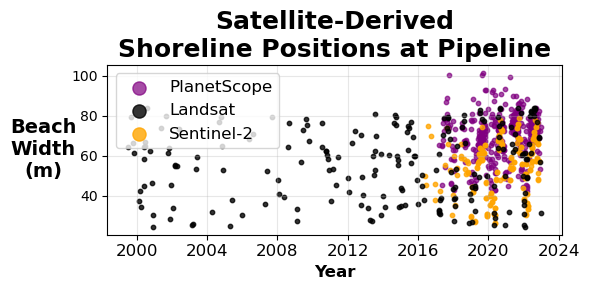

In [5]:
import matplotlib.dates as mdates

# ---- ENSURE DATETIME INDEX ----
df_planet.index = pd.to_datetime(df_planet.index)
df_coastsat.index = pd.to_datetime(df_coastsat.index)

# ---- CLIP DATA AFTER 1999 ----
start_date = "1999-01-01"
df_planet = df_planet[df_planet.index >= start_date]
df_coastsat = df_coastsat[df_coastsat.index >= start_date]


# ---- SPLIT COASTSAT INTO LANDSAT & SENTINEL ----
landsat_df = df_coastsat[df_coastsat["satname"].str.startswith("L")]
sentinel_df = df_coastsat[df_coastsat["satname"].str.startswith("S")]

# ---- CREATE FIGURE ----
plt.figure(figsize=(6,3))

# Planet (Blue)
plt.scatter(
    df_planet.index,
    df_planet[transect_col],
    color="purple",
    label="PlanetScope",
    alpha=0.7,
    s= 10,
    zorder = 0
)

# Landsat (Green)
plt.scatter(
    landsat_df.index,
    landsat_df[transect_col],
    color="black",
    label="Landsat",
    alpha=0.8,
    s= 10,
    zorder = 1
)

# Sentinel (Orange)
plt.scatter(
    sentinel_df.index,
    sentinel_df[transect_col],
    color="orange",
    label="Sentinel-2",
    alpha=0.8,
    s= 10,
    zorder = 0
)

# ---- LABELS ----
# ---- LABELS ----
plt.title("Satellite-Derived\nShoreline Positions at Pipeline",
          fontsize=18, fontweight="bold")

plt.xlabel("Year", fontsize=12, fontweight="bold")
plt.ylabel("Beach Width (m)", fontsize=14, fontweight="bold")


ax = plt.gca()

# ticks every 5 years
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# make ticks larger and bold
plt.xticks(fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize = 12, loc ='upper left', markerscale = 3)
plt.grid(alpha=0.3)
plt.ylabel("Beach\nWidth\n(m)", rotation=0,labelpad=20, va = 'center')
plt.tight_layout()
plt.gcf().savefig(os.path.join("Brian_figs", "satellite_sources" +transect_col+".png"), dpi=300, bbox_inches="tight")
plt.show()


# Calculate Mean Bias and apply correction

In [6]:

# ----------------------------------------------------
# Ensure datetime index
# ----------------------------------------------------

# --- Recompute overall means (2016-12-31 onward) ---
start_date = pd.Timestamp("2016-12-31").tz_localize(merged_planet_coast.index.tz)
df_filtered = merged_planet_coast.loc[start_date:]
df_filtered.index = pd.to_datetime(df_filtered.index)
df_filtered = df_filtered.sort_index()

# ----------------------------------------------------
# Identify transect columns
# ----------------------------------------------------
transect_cols = [col for col in df_filtered.columns if col.startswith("oahu")]

# ----------------------------------------------------
# Split by satellite type
# ----------------------------------------------------
planet_df = df_filtered[df_filtered["type"] == "PLANET"][transect_cols]
landsat_df = df_filtered[df_filtered["type"] == "LANDSAT"][transect_cols]
sentinel_df = df_filtered[df_filtered["type"] == "SENTINEL"][transect_cols]

# ----------------------------------------------------
# Resample to monthly means
# ----------------------------------------------------
planet_monthly = planet_df.resample("M").mean()
landsat_monthly = landsat_df.resample("M").mean()
sentinel_monthly = sentinel_df.resample("M").mean()

# ----------------------------------------------------
# Compute mean of monthly values (equal monthly weighting)
# ----------------------------------------------------
planet_mean = planet_monthly.mean()
landsat_mean = landsat_monthly.mean()
sentinel_mean = sentinel_monthly.mean()

# ----------------------------------------------------
# Build bias dataframe
# ----------------------------------------------------
bias_monthly_df = pd.DataFrame({
    "transect": transect_cols,
    "planet_monthly_mean": planet_mean.values,
    "landsat_monthly_mean": landsat_mean.values,
    "sentinel_monthly_mean": sentinel_mean.values,
})

bias_monthly_df["planet_minus_landsat"] = (
    bias_monthly_df["planet_monthly_mean"]
    - bias_monthly_df["landsat_monthly_mean"]
)

bias_monthly_df["planet_minus_sentinel"] = (
    bias_monthly_df["planet_monthly_mean"]
    - bias_monthly_df["sentinel_monthly_mean"]
)

bias_monthly_df

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\671262513.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  planet_monthly = planet_df.resample("M").mean()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\671262513.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  landsat_monthly = landsat_df.resample("M").mean()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\671262513.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sentinel_monthly = sentinel_df.resample("M").mean()


,transect,planet_monthly_mean,landsat_monthly_mean,sentinel_monthly_mean,planet_minus_landsat,planet_minus_sentinel
0,oahu0012_0001,96.144257,89.421134,85.337829,6.723122,10.806428
1,oahu0012_0002,91.870014,77.631074,72.663276,14.238940,19.206738
2,oahu0012_0003,97.581785,81.854386,77.688703,15.727399,19.893082
3,oahu0012_0004,103.598420,90.947056,86.126773,12.651364,17.471647
4,oahu0012_0005,101.032097,89.536218,83.058791,11.495879,17.973307
...,...,...,...,...,...,...
241,oahu0012_0242,17.512850,14.510383,7.271689,3.002467,10.241161
242,oahu0012_0243,17.030348,19.866683,11.642866,-2.836335,5.387482
243,oahu0012_0244,21.484675,27.391459,17.623625,-5.906784,3.861050
244,oahu0012_0245,24.792570,30.253337,19.647971,-5.460767,5.144599


# Plot shows bias is transect dependent and not global bias

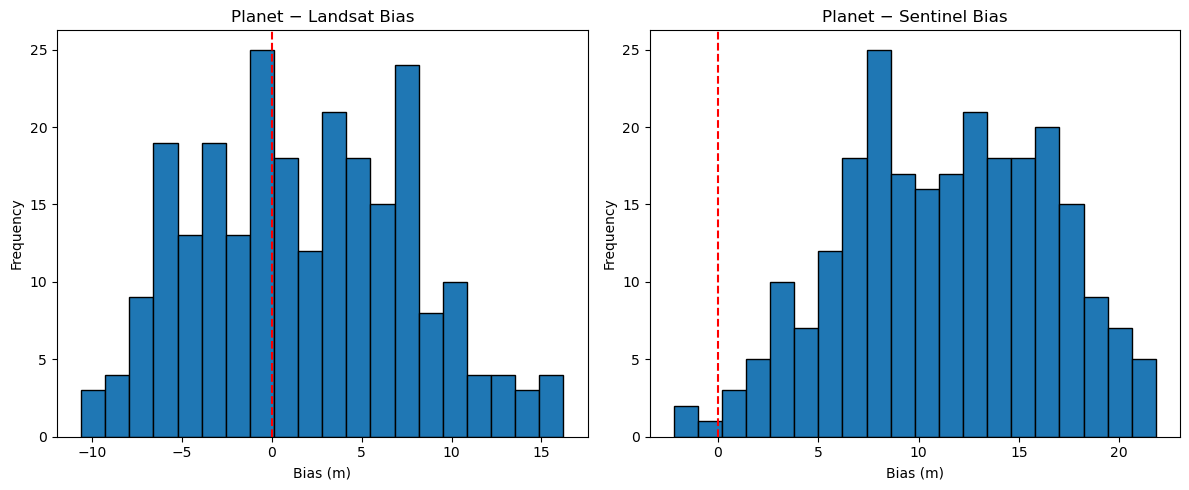

In [7]:
# Extract columns
bias_ls = bias_monthly_df["planet_minus_landsat"]
bias_sn = bias_monthly_df["planet_minus_sentinel"]

# Create figure
plt.figure(figsize=(12,5))

# Planet - Landsat
plt.subplot(1,2,1)
plt.hist(bias_ls.dropna(), bins=20, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Planet − Landsat Bias")
plt.xlabel("Bias (m)")
plt.ylabel("Frequency")

# Planet - Sentinel
plt.subplot(1,2,2)
plt.hist(bias_sn.dropna(), bins=20, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Planet − Sentinel Bias")
plt.xlabel("Bias (m)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
# --- Copy original dataset ---
merged_corrected = merged_planet_coast.copy()

# --- Identify transect columns ---
transect_cols = [col for col in merged_corrected.columns if col.startswith("oahu")]


satellite_means = (
    df_filtered
    .groupby("type")[transect_cols]
    .mean()
    .mean(axis=1)
)

# --------------------------------------------
# Copy dataset to preserve original
# --------------------------------------------
merged_corrected = merged_planet_coast.copy()

# Identify transect columns
transect_cols = bias_monthly_df["transect"].values

# --------------------------------------------
# Apply transect-by-transect correction
# --------------------------------------------
for _, row in bias_monthly_df.iterrows():
    
    transect = row["transect"]
    
    bias_ls = row["planet_minus_landsat"]
    bias_sn = row["planet_minus_sentinel"]
    
    # Correct LANDSAT
    merged_corrected.loc[
        merged_corrected["type"] == "LANDSAT",
        transect
    ] += bias_ls
    
    # Correct SENTINEL
    merged_corrected.loc[
        merged_corrected["type"] == "SENTINEL",
        transect
    ] += bias_sn

print("Per-transect monthly bias correction applied.")

Per-transect monthly bias correction applied.


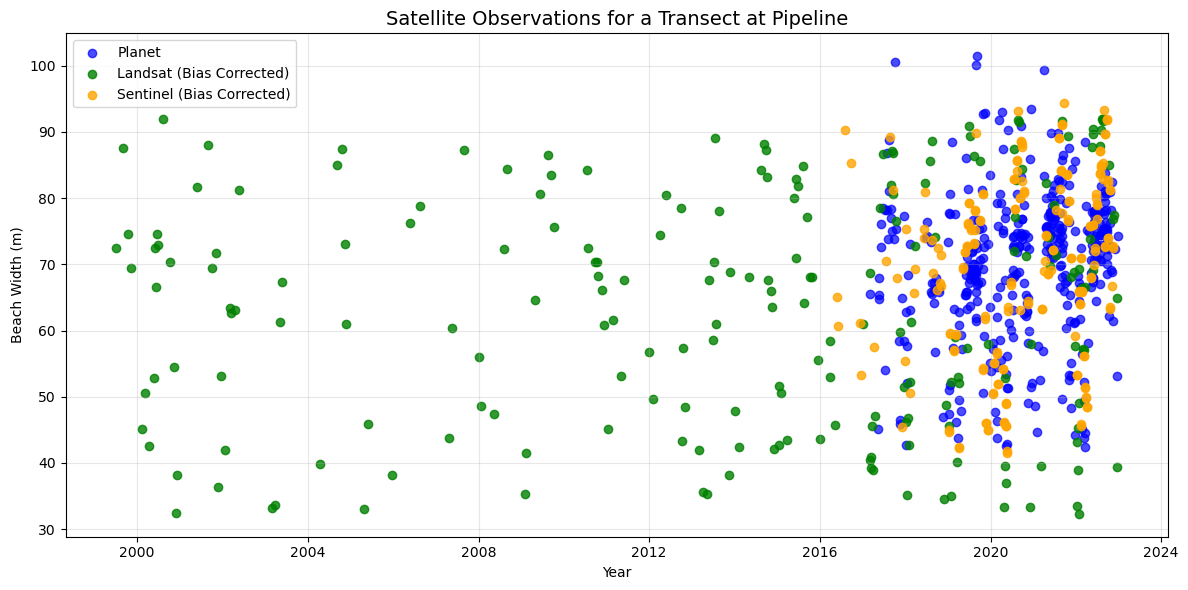

In [9]:

# ---- ENSURE DATETIME INDEX ----
merged_corrected.index = pd.to_datetime(merged_corrected.index)
merged_corrected = merged_corrected.sort_index()

# ---- DEFINE DATE RANGE (match timezone automatically) ----
tz = merged_corrected.index.tz
start_date = pd.Timestamp("1999-01-01").tz_localize(tz)
end_date = pd.Timestamp("2024-12-31").tz_localize(tz)

# ---- FILTER DATE RANGE ----
df_plot = merged_corrected.loc[start_date:end_date]

# ---- SPLIT BY TYPE ----
planet_df = df_plot[df_plot["type"] == "PLANET"]
landsat_df = df_plot[df_plot["type"] == "LANDSAT"]
sentinel_df = df_plot[df_plot["type"] == "SENTINEL"]

# ---- CREATE FIGURE ----
plt.figure(figsize=(12,6))

plt.scatter(planet_df.index, planet_df[transect_col],
            color="blue", label="Planet", alpha=0.7)

plt.scatter(landsat_df.index, landsat_df[transect_col],
            color="green", label="Landsat (Bias Corrected)", alpha=0.8)

plt.scatter(sentinel_df.index, sentinel_df[transect_col],
            color="orange", label="Sentinel (Bias Corrected)", alpha=0.8)

plt.title("Satellite Observations for a Transect at Pipeline", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Beach Width (m)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Read updated dataset

In [10]:
df_updated = pd.read_csv(os.path.join("NS-oahu0012-update", "oahu0012_intersects_outliersremoved_clean.csv"))
df_updated['timestamp'] = (
    pd.to_datetime(df_updated['timestamp'])                 # make sure it's datetime
    .dt.tz_localize('UTC')                      # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_updated = df_updated.set_index("timestamp")

In [11]:
# Ensure both are sorted
merged_planet_coast = merged_corrected.copy().sort_index()
df_updated = df_updated.sort_index()

# Get last timestamp from original dataframe
last_date = merged_planet_coast.index.max()

# Keep only newer rows from df_updated
df_updated_new = df_updated.loc[df_updated.index > last_date]

# Concatenate
merged_final = pd.concat([merged_planet_coast, df_updated_new]).sort_index()

### Resample to monthly medians (NO rolling

In [12]:
# monthly -> add merge key
def generate_transect_list(start_transect, end_transect):
    """Generate a list of transect IDs from start to end, inclusive."""
    return [f"oahu0012_{i:04d}" for i in range(start_transect, end_transect + 1)]
last_transect_number = 246
monthly_planet_coast  =  merged_final.resample('M').median(numeric_only=True)
monthly_median_planet_coast = monthly_planet_coast[monthly_planet_coast.index >= "1999-07-01"]

monthly_medians_stats = {'baseline_std': [], 'baseline_average': [], 'transect': []}
lst = list(range(1, last_transect_number +1))
for i in lst:
    transect =  generate_transect_list(start_transect = i, end_transect = i)[0]
    baseline_avg = monthly_planet_coast[transect].mean()
    baseline_std = monthly_planet_coast[transect].std()
    monthly_medians_stats['baseline_average'].append(baseline_avg)
    monthly_medians_stats['baseline_std'].append(baseline_std)
    monthly_medians_stats['transect'].append(transect)

monthly_medians_stats_raw  = pd.DataFrame(monthly_medians_stats)

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\1014326759.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_planet_coast  =  merged_final.resample('M').median(numeric_only=True)


#### rolling transect

In [13]:
# last_transect_number = 246
# lst = list(range(1, last_transect_number - 3))  # 1 to 244

# rolling_monthly_531 = monthly_planet_coast.copy()

# weights = np.array([1, 3, 5, 3, 1])
# weights = weights / weights.sum()   # normalize (sum = 13)

# for i in lst:
#     transects = generate_transect_list(start_transect=i, end_transect=i+4)
    
#     # center transect (same logic as before)
#     rolling_on_transect = transects[2]
    
#     # extract values as numpy array
#     values = monthly_planet_coast[transects].values
    
#     # apply weighted average row-wise
#     weighted = np.dot(values, weights)
    
#     rolling_monthly_531[rolling_on_transect] = weighted

# cols_to_drop = [
#     'oahu0012_0001',
#     'oahu0012_0002',
#     'oahu0012_0245',
#     'oahu0012_0246'
# ]

# rolling_monthly_median = rolling_monthly_531.drop(columns=cols_to_drop, errors='ignore')

# #5 TRANSECTS

# rolling_monthly_medians_stats = {'baseline_std': [], 'baseline_average': [], 'transect': []}
# lst = list(range(1+2, last_transect_number - 2))
# for i in lst:
#     transect =  generate_transect_list(start_transect = i, end_transect = i + 4)[0]
#     baseline_avg = rolling_monthly_median[transect].mean()
#     baseline_std = rolling_monthly_median[transect].std()
#     rolling_monthly_medians_stats['baseline_average'].append(baseline_avg)
#     rolling_monthly_medians_stats['baseline_std'].append(baseline_std)
#     rolling_monthly_medians_stats['transect'].append(transect)

# rolling_monthly_medians_stats  = pd.DataFrame(rolling_monthly_medians_stats )

### Evaluate a figure from a selected transect

In [14]:
transect = 'oahu0012_0044'
full_raw = merged_final[merged_final.index >= "1999-07-01"][[transect]].copy()
dataset = monthly_median_planet_coast
monthly_medians_stats = monthly_medians_stats_raw.copy()

#### View all data

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\187970547.py:113: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_month_index = pd.date_range(start=start, end=end, freq="M")


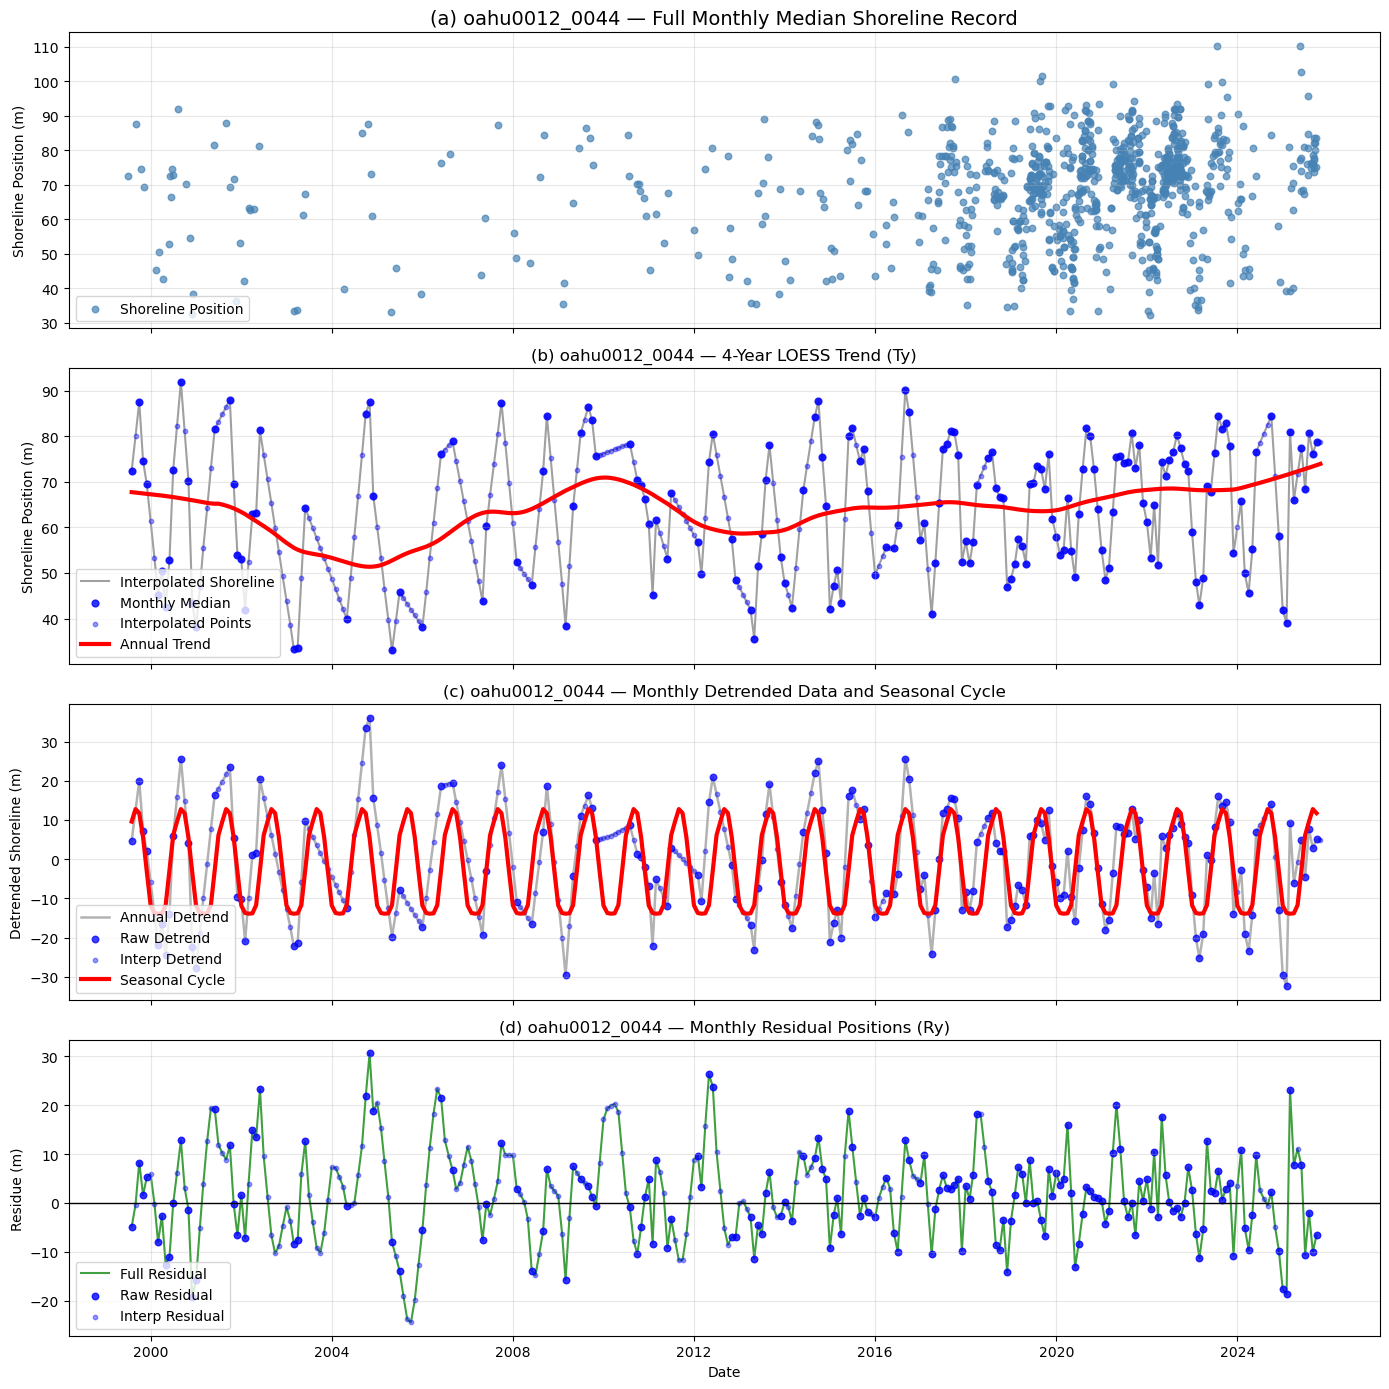

In [15]:
df_transect = dataset[[transect]].copy() #monthly and rolling

# ------------------------------------------------------------
# CREATE 4 SUBPLOTS WITH SHARED X-AXIS
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
(ax1, ax2, ax3, ax4) = axes


# ============================================================
# (a) FULL MONTHLY RECORD
# ============================================================
ax1.scatter(
    full_raw.index,
    full_raw[transect].values,
    s=22,
    alpha=0.7,
    color='steelblue',
    label='Shoreline Position'
)

ax1.set_title(f"(a) {transect} — Full Monthly Median Shoreline Record", fontsize=14)
ax1.set_ylabel("Shoreline Position (m)")
ax1.grid(alpha=0.3)
ax1.legend(loc="lower left")


# ============================================================
# (b) LOESS TREND PANEL
# ============================================================

series_orig = df_transect[transect].sort_index()
series_orig.index = pd.to_datetime(series_orig.index)

series_interp = series_orig.interpolate("linear")

y = series_interp.values
x = np.arange(len(y))
frac = 48 / len(y)

trend_vals = lowess(y, x, frac=frac, return_sorted=False)
trend = pd.Series(trend_vals, index=series_interp.index)

detrended_interannual = (series_orig - trend).dropna()
detrended_full = (series_interp - trend).copy()

raw_mask = series_orig.index
interp_mask = detrended_full.index.difference(series_orig.index)

ax2.plot(
    series_interp.index,
    series_interp.values,
    color="gray",
    alpha=0.75,
    zorder=1,
    label="Interpolated Shoreline"
)

ax2.scatter(
    series_orig.index,
    series_orig.values,
    s=24,
    color='blue',
    alpha=0.8,
    label='Monthly Median'
)

ax2.scatter(
    series_interp.index,
    series_interp.values,
    s=10,
    color='blue',
    alpha=0.4,
    label='Interpolated Points'
)

ax2.plot(
    trend.index,
    trend.values,
    color='red',
    linewidth=3,
    label='Annual Trend'
)

ax2.set_title(f"(b) {transect} — 4-Year LOESS Trend (Ty)")
ax2.set_ylabel("Shoreline Position (m)")
ax2.grid(alpha=0.3)
ax2.legend(loc="lower left")


# ============================================================
# (c) DETRENDED + SEASONAL CYCLE
# ============================================================

d = detrended_interannual.copy()
d.index = pd.to_datetime(d.index)

seasonal_median = (
    d.groupby(d.index.month)
     .median()
     .reindex(range(1,13))
)

months = np.arange(1,13)
smooth_vals = lowess(
    seasonal_median.values, months,
    frac=0.45, xvals=months, return_sorted=False
)
smooth_cycle = pd.Series(smooth_vals, index=months)

start = d.index.min().normalize()
end   = d.index.max().normalize()
full_month_index = pd.date_range(start=start, end=end, freq="M")

seasonal_full = pd.Series(
    [smooth_cycle[m] for m in full_month_index.month],
    index=full_month_index,
    name="Sy_full"
)

raw_mask = d.index
interp_mask = detrended_full.index.difference(d.index)

ax3.plot(
    detrended_full.index,
    detrended_full.values,
    color="gray",
    alpha=0.6,
    linewidth=1.8,
    zorder=1,
    label="Annual Detrend"
)

ax3.scatter(
    raw_mask,
    d.values,
    s=22,
    alpha=0.75,
    color="blue",
    label="Raw Detrend"
)

ax3.scatter(
    interp_mask,
    detrended_full.loc[interp_mask].values,
    s=10,
    color='blue',
    alpha=0.4,
    label="Interp Detrend"
)

ax3.plot(
    seasonal_full.index,
    seasonal_full.values,
    color="red",
    linewidth=3,
    label="Seasonal Cycle"
)

ax3.set_title(f"(c) {transect} — Monthly Detrended Data and Seasonal Cycle")
ax3.set_ylabel("Detrended Shoreline (m)")
ax3.grid(alpha=0.3)
ax3.legend(loc="lower left")


# ============================================================
# (d) RESIDUAL (Ry)
# ============================================================

Ry_full = detrended_full - seasonal_full.reindex(detrended_full.index)

Ry_raw = Ry_full.loc[raw_mask]
Ry_interp = Ry_full.loc[interp_mask]

ax4.plot(
    Ry_full.index, Ry_full.values,
    color="green", alpha=0.75, zorder=1,
    label="Full Residual"
)

ax4.scatter(
    Ry_raw.index, Ry_raw.values,
    s=22, color="blue", alpha=0.8,
    label="Raw Residual"
)

ax4.scatter(
    Ry_interp.index, Ry_interp.values,
    s=10, color="blue", alpha=0.4,
    label="Interp Residual"
)

ax4.axhline(0, color="black", linewidth=1)
ax4.set_title(f"(d) {transect} — Monthly Residual Positions (Ry)")
ax4.set_ylabel("Residue (m)")
ax4.set_xlabel("Date")
ax4.grid(alpha=0.3)
ax4.legend(loc="lower left")


# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()
plt.gcf().savefig(os.path.join("Brian_figs", "shoreline_decomposition" +transect+".png"), dpi=300, bbox_inches="tight")
plt.show()


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\1283516837.py:109: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_month_index = pd.date_range(start=start, end=end, freq="M")


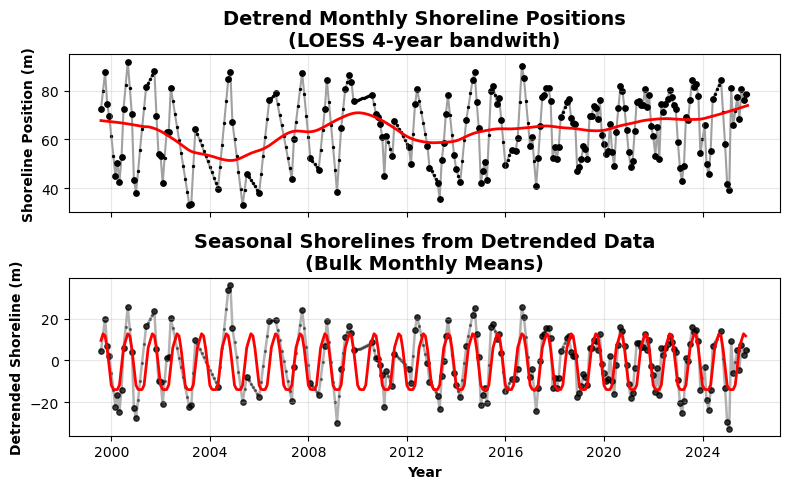

In [16]:
df_transect = dataset[[transect]].copy()

# ------------------------------------------------------------
# CREATE 2 SUBPLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
(ax1, ax2) = axes


# ============================================================
# (b) LOESS TREND PANEL
# ============================================================

series_orig = df_transect[transect].sort_index()
series_orig.index = pd.to_datetime(series_orig.index)

series_interp = series_orig.interpolate("linear")

y = series_interp.values
x = np.arange(len(y))
frac = 48 / len(y)

trend_vals = lowess(y, x, frac=frac, return_sorted=False)
trend = pd.Series(trend_vals, index=series_interp.index)

detrended_interannual = (series_orig - trend).dropna()
detrended_full = (series_interp - trend).copy()

raw_mask = series_orig.index
interp_mask = detrended_full.index.difference(series_orig.index)

ax1.plot(
    series_interp.index,
    series_interp.values,
    color="gray",
    alpha=0.75,
    zorder=1,
    label="Interpolated Shoreline"
)

ax1.scatter(
    series_orig.index,
    series_orig.values,
    s=15,
    color='black',
    alpha=1,
    label='Monthly Median'
)

ax1.scatter(
    series_interp.index,
    series_interp.values,
    s=2,
    color='black',
    alpha=1,
    label='Interpolated Points'
)

ax1.plot(
    trend.index,
    trend.values,
    color='red',
    linewidth=2,
    label='Annual Trend'
)

ax1.set_title(
    "Detrend Monthly Shoreline Positions\n(LOESS 4-year bandwith)",
    fontweight="bold", fontsize =14
)

ax1.set_ylabel(
    "Shoreline Position (m)",
    fontweight="bold"
)

ax1.grid(alpha=0.3)
#ax1.legend(loc="lower left")


# ============================================================
# (c) DETRENDED + SEASONAL CYCLE
# ============================================================

d = detrended_interannual.copy()
d.index = pd.to_datetime(d.index)

seasonal_median = (
    d.groupby(d.index.month)
     .median()
     .reindex(range(1,13))
)

months = np.arange(1,13)

smooth_vals = lowess(
    seasonal_median.values,
    months,
    frac=0.45,
    xvals=months,
    return_sorted=False
)

smooth_cycle = pd.Series(smooth_vals, index=months)

start = d.index.min().normalize()
end   = d.index.max().normalize()

full_month_index = pd.date_range(start=start, end=end, freq="M")

seasonal_full = pd.Series(
    [smooth_cycle[m] for m in full_month_index.month],
    index=full_month_index
)

raw_mask = d.index
interp_mask = detrended_full.index.difference(d.index)

ax2.plot(
    detrended_full.index,
    detrended_full.values,
    color="gray",
    alpha=0.6,
    linewidth=1.8,
    label="Annual Detrend",
    zorder=0
)

ax2.scatter(
    raw_mask,
    d.values,
    s=15,
    alpha=0.75,
    color="black",
    label="Raw Detrend"
)

ax2.scatter(
    interp_mask,
    detrended_full.loc[interp_mask].values,
    s=2,
    color='black',
    alpha=0.4,
    label="Interp Detrend"
)

ax2.plot(
    seasonal_full.index,
    seasonal_full.values,
    color="red",
    linewidth=2,
    label="Seasonal Cycle"
)

ax2.set_title(
    "Seasonal Shorelines from Detrended Data\n(Bulk Monthly Means)",
    fontweight="bold", fontsize = 14
)

ax2.set_ylabel(
    "Detrended Shoreline (m)",
    fontweight="bold"
)

ax2.set_xlabel(
    "Year",
    fontweight="bold"
)

ax2.grid(alpha=0.3)
#ax2.legend(loc="lower left")


# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()

plt.savefig(
    os.path.join("Brian_figs", f"shoreline_trend_seasonal_{transect}.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

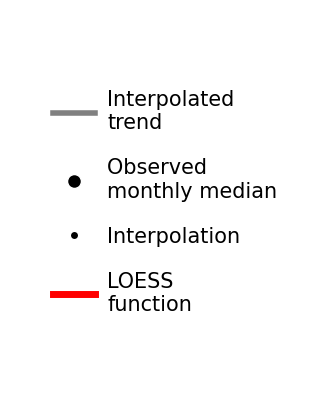

In [17]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import os

legend_elements = [
    Line2D([0],[0], color="gray", lw=4, label="Interpolated \ntrend"),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markersize=10, label="Observed \nmonthly median"),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markersize=6, label="Interpolation"),
    Line2D([0],[0], color="red", lw=5, label="LOESS \nfunction")
]

fig_leg = plt.figure(figsize=(4,5))

fig_leg.legend(
    handles=legend_elements,
    loc="center",
    ncol=1,                 # vertical stack
    frameon=False,
    columnspacing=0.8,
    handletextpad=0.6,
    handlelength=2,       # longer bars
    labelspacing=1.2,       # tighter stacking
    fontsize=15
)

plt.axis("off")

plt.savefig(
    os.path.join("Brian_figs","legend.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Evaluate Bulk Monthly Medians

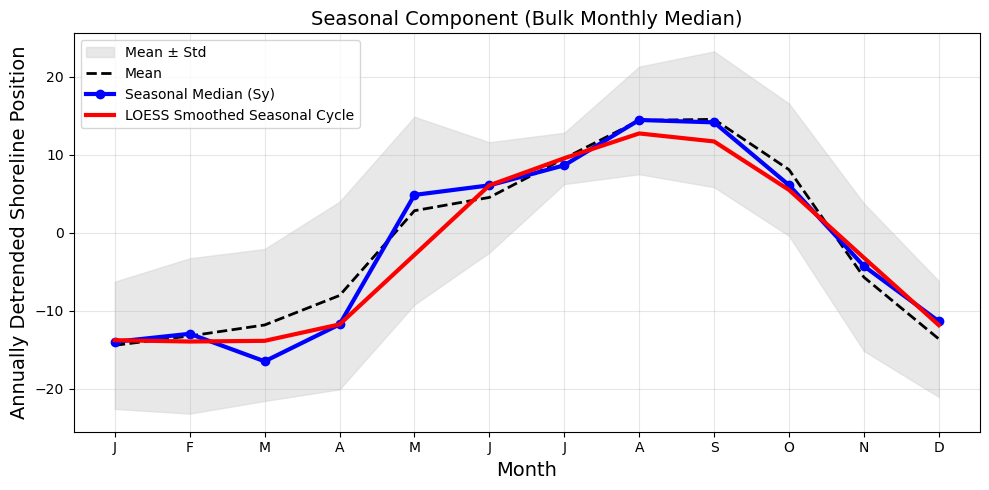

In [18]:
# -----------------------------------------------
# 1. RAW DETRENDED DATA (Sy + Ry)
# -----------------------------------------------
d = detrended_interannual.copy()
d.index = pd.to_datetime(d.index)

# -----------------------------------------------
# 2. MONTHLY STATISTICS
# -----------------------------------------------
seasonal_median = d.groupby(d.index.month).median().reindex(range(1,13))
seasonal_mean   = d.groupby(d.index.month).mean().reindex(range(1,13))
seasonal_std    = d.groupby(d.index.month).std().reindex(range(1,13))

months = np.arange(1,13)

# -----------------------------------------------
# 3. LOESS SMOOTH OF SEASONAL MEDIAN
# -----------------------------------------------
smooth_vals = lowess(
    seasonal_median.values,
    months,
    frac=0.45,
    xvals=months,
    return_sorted=False
)

smooth_cycle = pd.Series(smooth_vals, index=months)

# -----------------------------------------------
# 4. PLOT SEASONAL COMPONENT
# -----------------------------------------------
plt.figure(figsize=(10,5))

# Std shading
plt.fill_between(
    months,
    seasonal_mean - seasonal_std,
    seasonal_mean + seasonal_std,
    color='lightgray', alpha=0.5,
    label='Mean ± Std'
)

# Mean line
plt.plot(months, seasonal_mean, "k--", lw=2, label="Mean")

# Raw monthly medians
plt.plot(months, seasonal_median, "o-", lw=3, color="blue", label="Seasonal Median (Sy)")

# -----------------------------------------------
# LOESS-smoothed seasonal curve (RED)
# -----------------------------------------------
plt.plot(
    months,
    smooth_cycle.values,
    color="red",
    linewidth=3,
    label="LOESS Smoothed Seasonal Cycle"
)

# Formatting
plt.xticks(months, ["J","F","M","A","M","J","J","A","S","O","N","D"])
plt.title("Seasonal Component (Bulk Monthly Median)", fontsize=14)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Annually Detrended Shoreline Position", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.gcf().savefig(os.path.join("Brian_figs", f"shoreline_bulkmonthlymedian_{transect}.png"),
                  dpi=300, bbox_inches="tight")

plt.show()


# Loop through data: interpolate, detrend annual, determine seasonal cycle: tmax month, tmin month, tmin median, tmax median, stat test (1= significant)

In [19]:
# selecting the transect and following the detrending procedure for annual
seasonal_stats_storage = {
    'transect': [],
    'tmin_month': [],
    'tmax_month': [],
    'tmin_median': [],
    'tmax_median': [],
    't_maxmin_difference': [],
    't_test_results': [],
    'monthly_medians': []   # <-- NEW COLUMN
}

lst = list(range(1, last_transect_number + 1))

for i in lst:
    transect = generate_transect_list(start_transect=i, end_transect=i)[0]
    df_transect = dataset[[transect]].copy()
    
    series_orig = dataset[transect].sort_index()
    series_orig.index = pd.to_datetime(series_orig.index)
    
    series_interp = series_orig.interpolate("linear")
    
    y = series_interp.values
    x = np.arange(len(y))
    frac = 48 / len(y)
    
    trend_vals = lowess(y, x, frac=frac, return_sorted=False)
    trend = pd.Series(trend_vals, index=series_interp.index)
    
    detrended_interannual = (series_orig - trend).dropna()
    
    # -----------------------------------------------
    # 2. MONTHLY STATISTICS
    # -----------------------------------------------
    seasonal_median_months = detrended_interannual.groupby(
        detrended_interannual.index.month
    ).median().reindex(range(1, 13))

    seasonal_mean_months = detrended_interannual.groupby(
        detrended_interannual.index.month
    ).mean().reindex(range(1, 13))

    seasonal_std_months = detrended_interannual.groupby(
        detrended_interannual.index.month
    ).std().reindex(range(1, 13))


    # tmin and tmax
    tmin_month = seasonal_median_months.idxmin()
    tmin_position = seasonal_median_months.min()
    tmax_month = seasonal_median_months.idxmax()
    tmax_position = seasonal_median_months.max()

    # T-TEST significance
    months = detrended_interannual.index.month
    values_tmin = detrended_interannual[months == tmin_month]
    values_tmax = detrended_interannual[months == tmax_month]

    t_stat, p_value = ttest_ind(values_tmin, values_tmax, equal_var=False)
    stat_test = 1 if p_value < 0.05 else 0


    #standardize the monthly median values
    # Convert list → numpy array first
    arr = np.array(seasonal_median_months.values.tolist(), dtype=float)
    
    avg = arr.mean()
    std = arr.std()
    
    standardized_medians = (arr - avg) / std

        #ADD TO STORAGE
    seasonal_stats_storage['transect'].append(transect)
    seasonal_stats_storage['tmin_month'].append(tmin_month)
    seasonal_stats_storage['tmax_month'].append(tmax_month)
    seasonal_stats_storage['tmin_median'].append(tmin_position)
    seasonal_stats_storage['tmax_median'].append(tmax_position)
    seasonal_stats_storage['t_test_results'].append(stat_test)
    seasonal_stats_storage['t_maxmin_difference'].append(tmax_position - tmin_position)
        # === NEW: append 12-month vector ===
    seasonal_stats_storage["monthly_medians"].append(
        standardized_medians
    )


# Convert to dataframe
seasonal_stats_storage = pd.DataFrame(seasonal_stats_storage)

# Merge
merged_stats = monthly_medians_stats.merge(
    seasonal_stats_storage,
    on="transect",
    how="inner"
)

# Standardize amplitude
merged_stats['min_max_diff_standardized'] = (
    merged_stats['t_maxmin_difference'] - merged_stats['baseline_average']
) / merged_stats['baseline_std']

# Zero out amplitude for nonseasonal
merged_stats.loc[
    merged_stats['t_test_results'] == 0,
    'monthly_medians'
] = merged_stats.loc[
        merged_stats['t_test_results'] == 0,
        'monthly_medians'
    ].apply(lambda x: [0]*12)



In [20]:
merged_stats.t_test_results.value_counts()

t_test_results
1    242
0      4
Name: count, dtype: int64

# Apply K means to group transects

In [21]:
# Make sure every entry is a 1D array of length 12
def to_1d_array(x):
    arr = np.asarray(x).ravel()
    if arr.shape[0] != 12:
        raise ValueError(f"Found monthly_medians with length {arr.shape[0]} instead of 12")
    return arr

monthly_arrays = merged_stats["monthly_medians"].apply(to_1d_array)

# Stack into 2D matrix
monthly_matrix_z = np.vstack(monthly_arrays.to_list())
print("monthly_matrix_z shape:", monthly_matrix_z.shape)
# --------------------------------------------------
# 1. Extract standardized 12-month medians from storage
# --------------------------------------------------
monthly_matrix_z = np.array(merged_stats["monthly_medians"].to_list())
# shape: (N, 12)

# Sanity check
assert monthly_matrix_z.shape[1] == 12, "Each entry must contain 12 months"

# --------------------------------------------------
# 2. Compute month angles (1..12)
# --------------------------------------------------
months = np.arange(1, 13)
theta = 2 * np.pi * months / 12

month_sin = np.sin(theta)   # shape (12,)
month_cos = np.cos(theta)   # shape (12,)

# --------------------------------------------------
# 3. Build **modulated** circular features (correct 24-feature form)
# --------------------------------------------------
sin_features = monthly_matrix_z * month_sin          # (N × 12)
cos_features = monthly_matrix_z * month_cos          # (N × 12)

# --------------------------------------------------
# 4. Final feature matrix (N × 24)
# --------------------------------------------------
features = np.hstack([sin_features, cos_features])

print("Final feature matrix shape:", features.shape)
# should be (N, 24)


monthly_matrix_z shape: (246, 12)
Final feature matrix shape: (246, 24)


In [22]:
from sklearn.cluster import KMeans

k = 11 # from the paper

kmeans = KMeans(
    n_clusters=k,
    n_init=50,        # many random initializations = stable clusters
    max_iter=1000,    # more iterations = better convergence
    random_state=42
)

cluster_labels = kmeans.fit_predict(features)
merged_stats["cluster_label"] = cluster_labels

C:\Users\bgorberg\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\bgorberg\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\bgorberg\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bgorberg\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\bgorberg\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _w

In [23]:
nonseasonal_clusters = merged_stats.loc[
    merged_stats["t_test_results"] == 0, "cluster_label"
].unique()

Nonseasonal clusters: [4]


=== Correct Seasonal Cluster Order ===
Cluster 7: mean min-month ≈ 1.00
Cluster 2: mean min-month ≈ 3.08
Cluster 9: mean min-month ≈ 4.25
Cluster 1: mean min-month ≈ 5.52
Cluster 8: mean min-month ≈ 5.63
Cluster 10: mean min-month ≈ 6.00
Cluster 3: mean min-month ≈ 7.79
Cluster 6: mean min-month ≈ 8.00
Cluster 5: mean min-month ≈ 8.40
Cluster 0: mean min-month ≈ 9.85
Cluster 4: mean min-month ≈ inf
    cluster_label  mean_max_month
0               7            1.00
1               2            3.08
2               9            4.25
3               1            5.52
4               8            5.63
5              10            6.00
6               3            7.79
7               6            8.00
8               5            8.40
9               0            9.85
10              4             inf


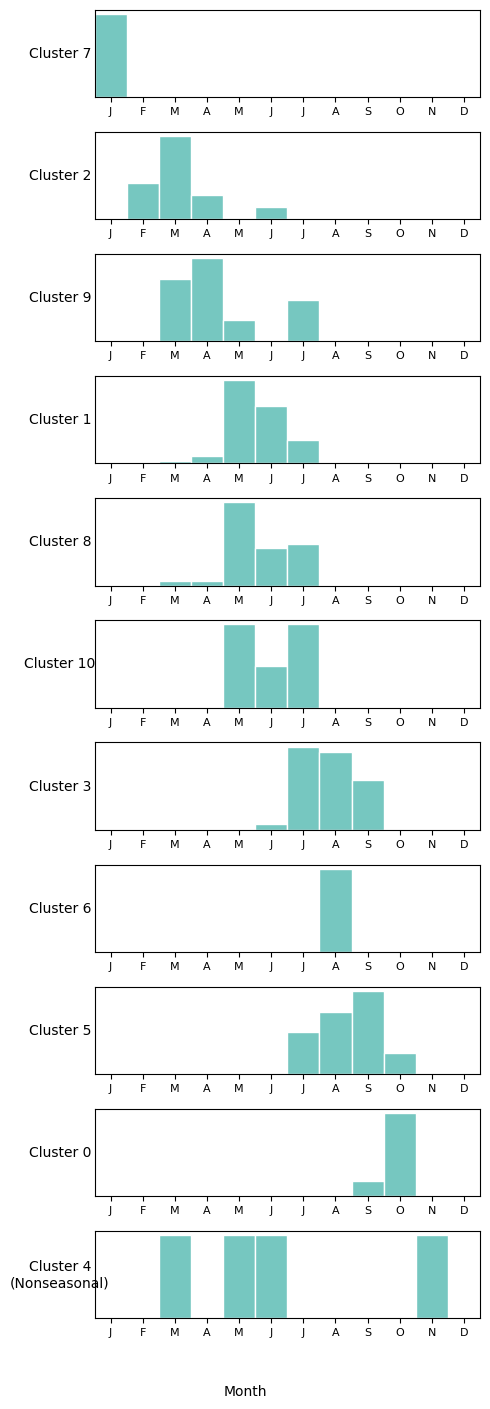

In [24]:
cluster_labels = merged_stats["cluster_label"].values
tmax_month = merged_stats["tmax_month"].values
unique_clusters = np.unique(cluster_labels)
month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

# -------------------------------------------------------
# STEP 1 — Identify nonseasonal clusters using t_test_results == 0
# -------------------------------------------------------
nonseasonal_clusters = merged_stats.loc[
    merged_stats["t_test_results"] == 0, "cluster_label"
].unique()

print("Nonseasonal clusters:", nonseasonal_clusters)

# -------------------------------------------------------
# STEP 2 — Compute mean-month per cluster (ignore nonseasonal)
# -------------------------------------------------------
import numpy as np

def circular_mean_month(months):
    """
    Compute circular mean of months (1–12) using radians.
    Returns mean month in range 1–12.
    """
    if len(months) == 0:
        return np.nan

    # Convert months to radians
    theta = 2 * np.pi * (months - 1) / 12

    mean_sin = np.mean(np.sin(theta))
    mean_cos = np.mean(np.cos(theta))

    mean_angle = np.arctan2(mean_sin, mean_cos)

    # Convert back to 1–12 month scale
    mean_month = ((mean_angle / (2 * np.pi)) * 12) + 1
    if mean_month <= 0:
        mean_month += 12

    return mean_month


# ---------------------------------------------------
# Compute circular mean month for each cluster
# ---------------------------------------------------
cluster_mean_month = {}

unique_clusters = np.unique(cluster_labels)

for cid in unique_clusters:

    # Extract months for this cluster
    months = tmax_month[cluster_labels == cid]

    if cid in nonseasonal_clusters:      # nonseasonal class (flat pattern)
        cluster_mean_month[cid] = np.inf # push to END
    else:
        cluster_mean_month[cid] = circular_mean_month(months)

# ---------------------------------------------------
# Sort clusters by circular seasonal order
# ---------------------------------------------------
sorted_clusters = sorted(
    cluster_mean_month.keys(),
    key=lambda c: cluster_mean_month[c]
)

print("\n\n=== Correct Seasonal Cluster Order ===")
for c in sorted_clusters:
    print(f"Cluster {c}: mean min-month ≈ {cluster_mean_month[c]:.2f}")

cluster_mean_month_df = pd.DataFrame({
    "cluster_label": sorted_clusters,
    "mean_max_month": [round(cluster_mean_month[c], 2) for c in sorted_clusters]
})

print(cluster_mean_month_df)

# -------------------------------------------------------
# STEP 3 — Plot
# -------------------------------------------------------
fig, axes = plt.subplots(len(sorted_clusters), 1, figsize=(5, len(sorted_clusters) * 1.3))

for i, cluster_id in enumerate(sorted_clusters):
    ax = axes[i]
    data = tmax_month[cluster_labels == cluster_id]

    bins = np.arange(1, 14)
    ax.hist(data, bins=bins, color="#76c7c0", edgecolor="white")

    ax.set_xlim(1, 13)
    ax.set_xticks(np.arange(1.5, 13.5, 1))
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_yticks([])

    # Label: add "Nonseasonal" if applicable
    if cluster_id in nonseasonal_clusters:
        label_text = f"Cluster {cluster_id}\n(Nonseasonal)"
    else:
        label_text = f"Cluster {cluster_id}"

    ax.set_ylabel(label_text, rotation=0, labelpad=25, va='center')

fig.text(0.5, 0.02, "Month", ha='center', fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])

# SAVE BEFORE SHOWING
os.makedirs("Brian_figs", exist_ok=True)
fig.savefig(
    os.path.join("Brian_figs", "clusters_tmax.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
merged_stats = merged_stats.merge(
    cluster_mean_month_df,
    on="cluster_label",
    how="left"
)

In [26]:
# Inputs
cluster_labels = merged_stats["cluster_label"].values
tmax_month = merged_stats["tmax_month"].values
unique_clusters = np.unique(cluster_labels)

# -------------------------------------------------------
# STEP 1 — Identify nonseasonal clusters (t_test_results == 0)
# -------------------------------------------------------
nonseasonal_clusters = merged_stats.loc[
    merged_stats["t_test_results"] == 0,
    "cluster_label"
].unique()

print("Nonseasonal clusters:", nonseasonal_clusters)

# -------------------------------------------------------
# STEP 2 — Compute mean month for seasonal clusters
# -------------------------------------------------------
def circular_mean_month(months):
    """
    Compute circular mean of months (1–12) using radians.
    Returns mean month in range 1–12.
    """
    if len(months) == 0:
        return np.nan

    # Convert months to radians
    theta = 2 * np.pi * (months - 1) / 12

    mean_sin = np.mean(np.sin(theta))
    mean_cos = np.mean(np.cos(theta))

    mean_angle = np.arctan2(mean_sin, mean_cos)

    # Convert back to 1–12 month scale
    mean_month = ((mean_angle / (2 * np.pi)) * 12) + 1
    if mean_month <= 0:
        mean_month += 12

    return mean_month


# ---------------------------------------------------
# Compute circular mean month for each cluster
# ---------------------------------------------------
# ---------------------------------------------------
# ---------------------------------------------------
# STEP 3b — Assign new ranks to each cluster
# ---------------------------------------------------
new_cluster_rank = {}
rank = 1

for cid in sorted_clusters:
    if cid in nonseasonal_clusters:
        new_cluster_rank[cid] = 10
    else:
        new_cluster_rank[cid] = rank
        rank += 1

# ---------------------------------------------------
# STEP 4 — Apply new labels into merged_stats
# ---------------------------------------------------
merged_stats["cluster_label_ranked"] = merged_stats["cluster_label"].map(new_cluster_rank)

# ---------------------------------------------------
# Sort clusters by circular seasonal order
# ---------------------------------------------------
sorted_clusters = sorted(
    cluster_mean_month.keys(),
    key=lambda c: cluster_mean_month[c]
)

print("\n\n=== Correct Seasonal Cluster Order ===")
for c in sorted_clusters:
    print(f"Cluster {c}: mean min-month ≈ {cluster_mean_month[c]:.2f}")

# -------------------------------------------------------
# STEP 4 — Apply new labels into merged_stats
# -------------------------------------------------------
merged_stats["cluster_label_ranked"] = merged_stats["cluster_label"].map(new_cluster_rank)


Nonseasonal clusters: [4]


=== Correct Seasonal Cluster Order ===
Cluster 7: mean min-month ≈ 1.00
Cluster 2: mean min-month ≈ 3.08
Cluster 9: mean min-month ≈ 4.25
Cluster 1: mean min-month ≈ 5.52
Cluster 8: mean min-month ≈ 5.63
Cluster 10: mean min-month ≈ 6.00
Cluster 3: mean min-month ≈ 7.79
Cluster 6: mean min-month ≈ 8.00
Cluster 5: mean min-month ≈ 8.40
Cluster 0: mean min-month ≈ 9.85
Cluster 4: mean min-month ≈ inf


### Save Seasonal Ranking for 

In [29]:
# 1. Load the transect GeoJSON file
# -------------------------------------------------------
transects = gpd.read_file("oahu_20231127_transects_epsg3750.geojson")
transects = transects[ transects["id"].str.startswith("oahu0012") ].copy()
merged_stats["id"] = merged_stats["transect"].astype(str)

# -------------------------------------------------------
# 5. Merge only the Oahu0012 point layer
# -------------------------------------------------------
merged = transects.merge(
    merged_stats,
    on="id",
    how="left"
)
merged["mean_max_month_shifted_for_ARCGIS"] = ((merged["mean_max_month"] - 10) % 12) + 1

In [32]:
merged.to_csv("Results_For_Volume_Change.csv")

# Cut and label the transects

In [33]:
import geopandas as gpd
from shapely.ops import substring
import pandas as pd

# Define the cutting functions
def cut_line_starting_at_0(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, 0, distance)

def cut_line_starting_at_end_length(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, length - distance, length)


# ===================== 1. BETWEEN MEAN MIN AND MEAN MAX =====================

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['baseline_average'] +row['tmax_median']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['tmax_median'] - row['tmin_median'])
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
notebook_dir = Path.cwd()
output_folder = notebook_dir / "Brian_shapefile_output_max_beach"
output_path = output_folder/ "NS_transects_max_MEDIAN_SEASONAL.shp"
merged.to_file(output_path)


# --- Ensure cluster_label_ranked is numeric ---
merged["cluster_label_ranked"] = pd.to_numeric(
    merged["cluster_label_ranked"], errors="coerce"
)

# --- Subset by cluster groups ---
nonseasonal = merged[merged["cluster_label"] == nonseasonal_clusters[0]].copy()
winter = merged[
    ((merged["mean_max_month"] >= 10) & (merged["mean_max_month"] <= 12)) |
    ((merged["mean_max_month"] >= 0) & (merged["mean_max_month"] < 4))
].copy()

summer = merged[
    (merged["mean_max_month"] > 4) & (merged["mean_max_month"] < 10)
].copy()

# --- Output folder ---

from pathlib import Path

# folder where Jupyter is running from



output_folder.mkdir(exist_ok=True)

# --- Write shapefiles ---
nonseasonal.to_file(os.path.join(output_folder, "NS_transects_max_NONSEASONAL.shp"))
winter.to_file(os.path.join(output_folder, "NS_transects_max_WINTER.shp"))
summer.to_file(os.path.join(output_folder, "NS_transects_max_SUMMER.shp"))

print("Shapefiles successfully written.")

Shapefiles successfully written.


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\649383622.py:47: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_std' to 'baseline_s'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_average' to 'baseline_a'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'tmin_median' to 'tmin_media'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'tmax_median' to 'tmax_media'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 't_maxmin_difference' to 't_maxmin_d'
  ogr_wri